# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import train_test_split

print("Libraries Loaded✅")

Libraries Loaded✅


# **Data Exploration**

## *Load The Data*

In [2]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Logistic Regression\\Employees attrition\\Data\\employee_attrition.csv")
print("Data Loaded")

Data Loaded


## *Exploration*

In [3]:
print(f"Shape {df.shape}")

Shape (612, 8)


In [4]:
print("First 5 Rows")
df.head()

First 5 Rows


,satisfaction_score,salary_lakh,years_at_company,promotions_last_5yr,weekly_hours,num_projects,manager_rating,left_company
0,1.2,32.9,10.0,2.0,60.0,4.0,NaN,1
1,2.3,12.3,16.0,0.0,59.0,6.0,2.3,1
2,3.0,33.5,15.0,2.0,50.0,1.0,2.1,0
3,1.9,6.2,6.0,2.0,49.0,7.0,1.5,1
4,9.0,35.0,3.0,0.0,60.0,5.0,3.0,1


In [5]:
print("Last 5 Rows")
df.tail()

Last 5 Rows


,satisfaction_score,salary_lakh,years_at_company,promotions_last_5yr,weekly_hours,num_projects,manager_rating,left_company
607,2.1,8.1,7.0,2.0,47.0,7.0,2.6,1
608,4.2,25.9,9.0,2.0,53.0,2.0,2.9,0
609,4.0,17.8,18.0,1.0,67.0,6.0,1.4,1
610,3.1,26.2,14.0,4.0,54.0,2.0,4.7,0
611,3.8,29.5,12.0,0.0,55.0,2.0,1.7,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   satisfaction_score   592 non-null    float64
 1   salary_lakh          612 non-null    object 
 2   years_at_company     612 non-null    float64
 3   promotions_last_5yr  612 non-null    float64
 4   weekly_hours         612 non-null    float64
 5   num_projects         612 non-null    float64
 6   manager_rating       592 non-null    float64
 7   left_company         612 non-null    int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 38.4+ KB


In [7]:
df.describe()

,satisfaction_score,years_at_company,promotions_last_5yr,weekly_hours,num_projects,manager_rating,left_company
count,592.000000,612.000000,612.000000,612.000000,612.000000,592.000000,612.000000
mean,2.931081,9.441176,1.870915,52.767974,4.006536,2.940034,0.428105
std,1.161500,5.648585,1.425052,11.635845,2.045303,1.152457,0.495209
min,1.000000,-3.000000,0.000000,35.000000,1.000000,1.000000,0.000000
25%,2.000000,5.000000,1.000000,44.000000,2.000000,1.900000,0.000000
50%,2.900000,10.000000,2.000000,53.000000,4.000000,2.850000,0.000000
75%,3.900000,14.000000,3.000000,61.000000,6.000000,3.900000,1.000000
max,9.000000,19.000000,4.000000,200.000000,7.000000,5.000000,1.000000


## Data Findings
* Year at company have some impossible values like -3 year 
* Weekly hours have some outliers like 200 hours 

# **Data Cleaning**

In [12]:
df_copy  = df.copy()

## Data Type Correction

In [13]:
df_copy['salary_lakh'] = pd.to_numeric(df['salary_lakh'], errors= 'coerce').astype('float64')

## *impossible Values*

In [14]:
# Years at company
# Weekly Hours
df_copy.loc[df_copy['years_at_company']<=0,'years_at_company'] = np.nan
df_copy.loc[df_copy['weekly_hours']==200,'weekly_hours'] = np.nan

# No outliers in the data

## *NaN Values*

In [ ]:
print("NaN values before: ")
print(df_copy.isna().sum())

df_copy['satisfaction_score'] = df_copy['satisfaction_score'].fillna(round(df_copy['satisfaction_score'].median(),2))
df_copy['salary_lakh'] = df_copy['salary_lakh'].fillna(round(df_copy['salary_lakh'].median(),2))
df_copy['years_at_company'] = df_copy['years_at_company'].fillna(round(df_copy['years_at_company'].median(),2))
df_copy['weekly_hours'] = df_copy['weekly_hours'].fillna(round(df_copy['weekly_hours'].median(),2))
df_copy['manager_rating'] = df_copy['manager_rating'].fillna(round(df_copy['manager_rating'].median(),2))
print('\nNaN values after: ')
print(df_copy.isna().sum())


NaN values before: 
satisfaction_score     20
salary_lakh             5
years_at_company       29
promotions_last_5yr     0
weekly_hours            1
num_projects            0
manager_rating         20
left_company            0
dtype: int64
NaN values after: 
satisfaction_score     0
salary_lakh            0
years_at_company       0
promotions_last_5yr    0
weekly_hours           0
num_projects           0
manager_rating         0
left_company           0
dtype: int64


## *Duplicates Handaling*

In [17]:
print(f"Duplicates before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"Duplicates After: {df_copy.duplicated().sum()}")

Duplicates before: 12
Duplicates After: 0


## **Data Preperation**

In [19]:
X = df_copy[['satisfaction_score','salary_lakh','years_at_company','promotions_last_5yr','weekly_hours','num_projects','manager_rating']]
y = df_copy['left_company']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (600, 7)
y Shape: (600,)


In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (480, 7)
y_train Shape: (480,)
X_test Shape: (120, 7)
y_test Shape: (120,)


# **Model**

## *Train*

In [21]:
model = LogisticRegression()

model.fit(X_train,y_train)

print("model Trained")

model Trained


## *Test*

In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred,
    'Probability': y_prob.round(3)
})
print(comparison.head(10))

   Actual  Predicted  Probability
0       1          1        0.907
1       1          1        0.933
2       0          0        0.393
3       1          1        0.997
4       0          0        0.034
5       0          0        0.030
6       0          0        0.092
7       0          0        0.049
8       0          0        0.039
9       0          0        0.119


## *Evaluation*

In [24]:
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))

Accuracy:  0.9417
Precision: 0.94
Recall:    0.9216
F1 Score:  0.9307


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        69
           1       0.94      0.92      0.93        51

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



## *Confussion Matrix*

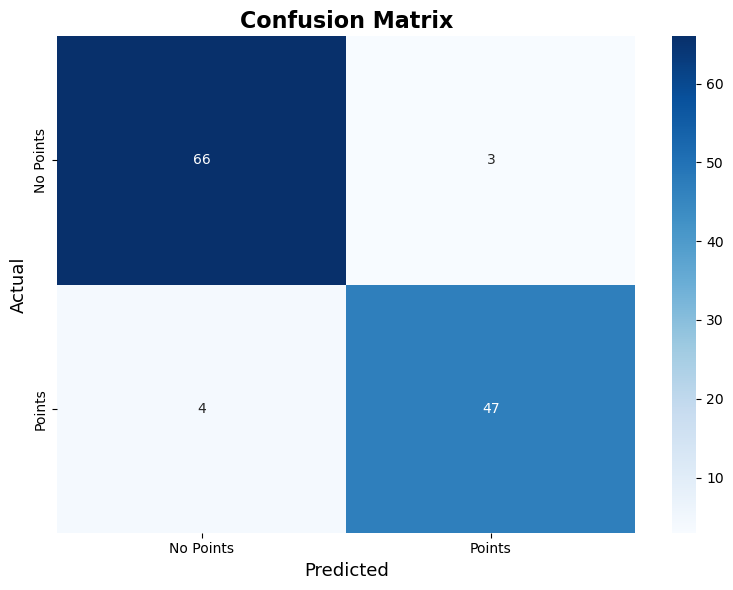

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## *Coefficent*

In [26]:
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25} → {coef:.4f}")

Feature Coefficients:
  satisfaction_score        → -1.7519
  salary_lakh               → -0.1150
  years_at_company          → -0.2552
  promotions_last_5yr       → -0.7670
  weekly_hours              → 0.1509
  num_projects              → 0.3680
  manager_rating            → -0.8413


# **Charts**

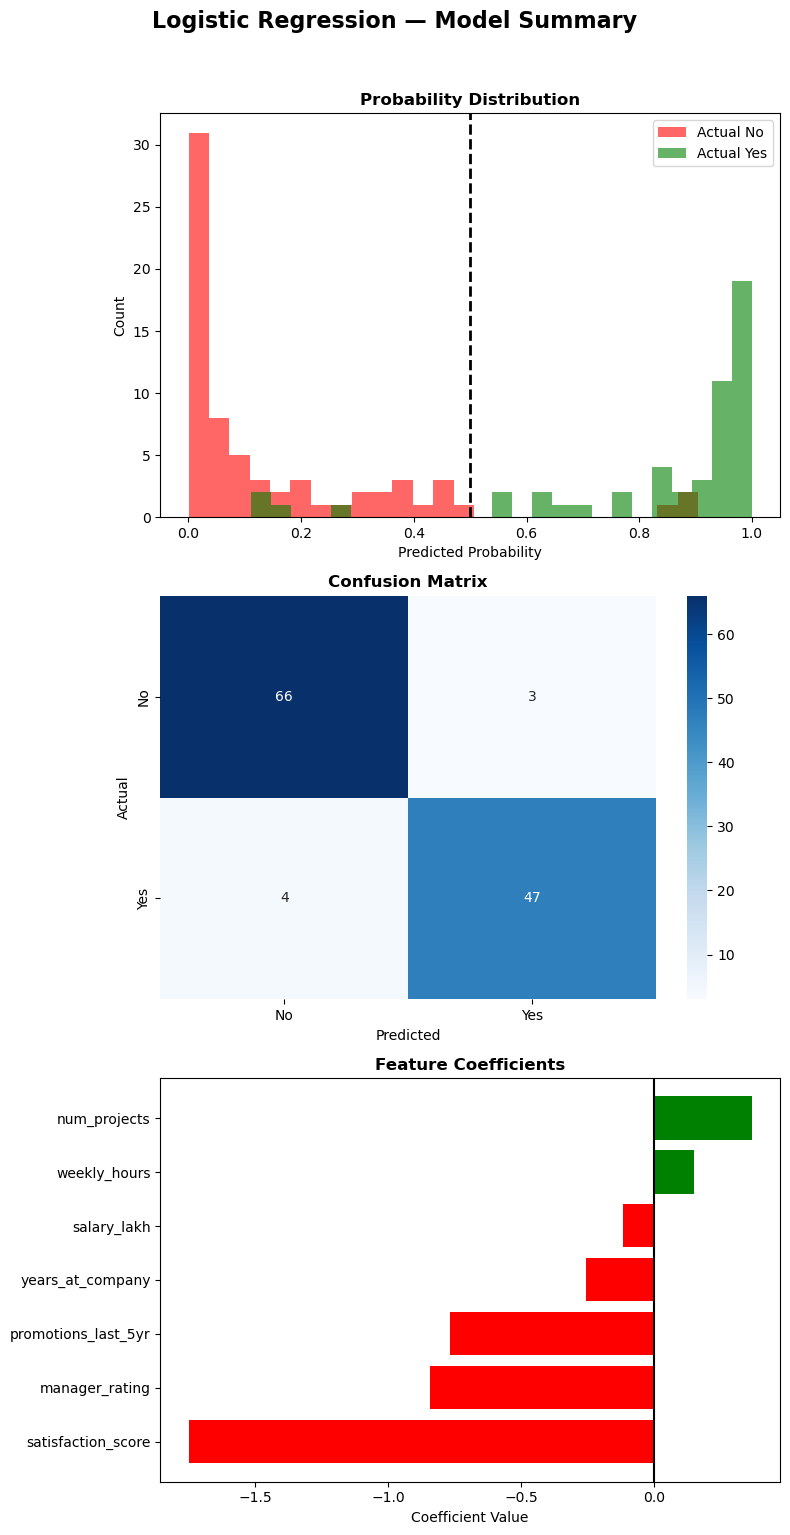

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
